In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import folium
from math import radians, sin, cos, sqrt, atan2

print("Librerías cargadas")

Librerías cargadas


In [2]:
df = pd.read_csv("trazabilidad_soja.csv")

# Conversión de tipos
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Filas: {len(df)}  |  Columnas: {len(df.columns)}")
print(f"Período: {df['timestamp'].iloc[0]}  →  {df['timestamp'].iloc[-1]}")
df.head(5)

Filas: 57  |  Columnas: 18
Período: 2026-05-15 06:00:00  →  2026-05-22 06:00:00


,registro_id,timestamp,lote_id,producto,etapa,evento,ubicacion,lat,lon,transporte,humedad_grano_pct,temperatura_grano_c,temperatura_ambiente_c,humedad_ambiente_pct,shock_g,estado_sello,responsable,observaciones
0,TRZ-0001,2026-05-15 06:00:00,SOJA-ITP-2026-001,Soja a granel,SILO,CARGA_SILO,Silo Itapúa,-27.338000,-55.86600,Camión,12.47,23.9,26.6,63.5,0.17,OK,Cooperativa Itapúa,Registro automático de telemetría IoT.
1,TRZ-0002,2026-05-15 09:00:00,SOJA-ITP-2026-001,Soja a granel,SILO,CONTROL_CALIDAD_ORIGEN,Tramo Silo Itapúa - Puerto Encarnación,-27.334000,-55.86800,Camión,12.63,24.5,30.4,63.1,0.08,OK,Cooperativa Itapúa,Lote habilitado para despacho.
2,TRZ-0003,2026-05-15 12:00:00,SOJA-ITP-2026-001,Soja a granel,PUERTO_ORIGEN,SALIDA_SILO_A_PUERTO,Puerto Encarnación,-27.330000,-55.87000,Camión,12.33,25.5,31.1,66.2,0.13,OK,Cooperativa Itapúa,Registro automático de telemetría IoT.
3,TRZ-0004,2026-05-15 15:00:00,SOJA-ITP-2026-001,Soja a granel,PUERTO_ORIGEN,CARGA_BARCAZA,Tramo Puerto Encarnación - San Cosme y Damián,-27.325125,-56.04625,Barcaza,12.37,26.0,31.2,65.5,1.03,OK,Operador Hidrovía,Registro automático de telemetría IoT.
4,TRZ-0005,2026-05-15 18:00:00,SOJA-ITP-2026-001,Soja a granel,TRANSITO_FLUVIAL,SALIDA_BARCAZA,Tramo Puerto Encarnación - San Cosme y Damián,-27.320250,-56.22250,Barcaza,12.64,26.0,26.3,76.0,0.16,OK,Operador Hidrovía,Registro automático de telemetría IoT.


In [4]:
print("=" * 55)
print("INFORMACIÓN GENERAL")
print("=" * 55)
print(f"Lote ID : {df['lote_id'].unique()[0]}")
print(f"Producto: {df['producto'].unique()[0]}")
print()

print("COLUMNAS Y TIPOS DE DATOS")
print(df.dtypes.to_string())
print()

print("VALORES FALTANTES")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.any() else "  → Sin valores faltantes")
print()

print("EVENTOS REGISTRADOS")
print(df["evento"].value_counts().to_string())
print()

print("ETAPAS DEL TRAYECTO")
print(df["etapa"].value_counts().to_string())
print()

print("COORDENADAS GPS DISPONIBLES")
print(f"  Lat: {df['lat'].min():.4f}  a  {df['lat'].max():.4f}")
print(f"  Lon: {df['lon'].min():.4f}  a  {df['lon'].max():.4f}")
print(f"  Registros con GPS: {df[['lat','lon']].notna().all(axis=1).sum()} / {len(df)}")

INFORMACIÓN GENERAL
Lote ID : SOJA-ITP-2026-001
Producto: Soja a granel

COLUMNAS Y TIPOS DE DATOS
registro_id                       object
timestamp                 datetime64[ns]
lote_id                           object
producto                          object
etapa                             object
evento                            object
ubicacion                         object
lat                              float64
lon                              float64
transporte                        object
humedad_grano_pct                float64
temperatura_grano_c              float64
temperatura_ambiente_c           float64
humedad_ambiente_pct             float64
shock_g                          float64
estado_sello                      object
responsable                       object
observaciones                     object

VALORES FALTANTES
  → Sin valores faltantes

EVENTOS REGISTRADOS
evento
TELEMETRIA                44
CARGA_SILO                 1
CONTROL_CALIDAD_ORIGEN     1
SAL

In [5]:
# Origen y destino
origen  = df.iloc[0]
destino = df.iloc[-1]
print(f"Origen : {origen['ubicacion']}  ({origen['timestamp']})")
print(f"Destino: {destino['ubicacion']}  ({destino['timestamp']})")

# Tiempo total de viaje
tiempo_total = destino["timestamp"] - origen["timestamp"]
horas_totales = tiempo_total.total_seconds() / 3600
print(f"\nTiempo total de viaje: {tiempo_total}  ({horas_totales:.1f} horas)")

# Distancia recorrida con fórmula de Haversine
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # Radio Tierra en km
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi / 2)**2 + cos(phi1) * cos(phi2) * sin(dlambda / 2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

distancias = []
for i in range(len(df) - 1):
    d = haversine(df.loc[i, "lat"], df.loc[i, "lon"],
                  df.loc[i+1, "lat"], df.loc[i+1, "lon"])
    distancias.append(d)

distancia_total = sum(distancias)
print(f"Distancia estimada recorrida (Haversine): {distancia_total:.1f} km")

# Medios de transporte utilizados
print(f"\nMedios de transporte: {df['transporte'].unique()}")

Origen : Silo Itapúa  (2026-05-15 06:00:00)
Destino: Nueva Palmira  (2026-05-22 06:00:00)

Tiempo total de viaje: 7 days 00:00:00  (168.0 horas)
Distancia estimada recorrida (Haversine): 1242.9 km

Medios de transporte: ['Camión' 'Barcaza' 'Puerto destino']


In [6]:
# Centro del mapa
lat_center = df["lat"].mean()
lon_center = df["lon"].mean()

mapa = folium.Map(location=[lat_center, lon_center], zoom_start=6, tiles="CartoDB positron")

# Paleta de colores por etapa
colores_etapa = {
    "SILO":             "#2196F3",  # azul
    "PUERTO_ORIGEN":    "#FF9800",  # naranja
    "TRANSITO_FLUVIAL": "#4CAF50",  # verde
    "PUERTO_DESTINO":   "#F44336",  # rojo
}

# Línea de ruta
coords = list(zip(df["lat"], df["lon"]))
folium.PolyLine(coords, color="#1565C0", weight=2.5, opacity=0.7, tooltip="Ruta Hidrovía").add_to(mapa)

# Marcadores de eventos clave
eventos_clave = [
    "CARGA_SILO", "CARGA_BARCAZA", "CONTROL_INTERMEDIO",
    "PASO_CONFLUENCIA", "LLUVIA_EN_RUTA", "ALERTA_HUMEDAD",
    "VENTILACION_BODEGA", "INSPECCION_ZARATE",
    "ARRIBO_NUEVA_PALMIRA", "DESCARGA_PUERTO",
]
iconos = {
    "CARGA_SILO":           ("home",       "blue"),
    "CARGA_BARCAZA":        ("anchor",     "orange"),
    "CONTROL_INTERMEDIO":   ("info-sign",  "green"),
    "PASO_CONFLUENCIA":     ("map-marker", "purple"),
    "LLUVIA_EN_RUTA":       ("cloud",      "cadetblue"),
    "ALERTA_HUMEDAD":       ("warning-sign","red"),
    "VENTILACION_BODEGA":   ("refresh",    "lightgreen"),
    "INSPECCION_ZARATE":    ("search",     "darkblue"),
    "ARRIBO_NUEVA_PALMIRA": ("flag",       "darkred"),
    "DESCARGA_PUERTO":      ("ok-sign",    "green"),
}

for _, row in df.iterrows():
    color_circ = colores_etapa.get(row["etapa"], "#9E9E9E")
    popup_txt = (f"<b>{row['evento']}</b><br>"
                 f"{row['ubicacion']}<br>"
                 f"{row['timestamp']}<br>"
                 f"Humedad grano: <b>{row['humedad_grano_pct']}%</b><br>"
                 f"Temp grano: {row['temperatura_grano_c']}°C<br>"
                 f"{row['transporte']} | Etapa: {row['etapa']}")

    if row["evento"] in eventos_clave:
        icono, color_icon = iconos.get(row["evento"], ("circle", "gray"))
        folium.Marker(
            location=[row["lat"], row["lon"]],
            popup=folium.Popup(popup_txt, max_width=280),
            tooltip=row["evento"],
            icon=folium.Icon(color=color_icon, icon=icono, prefix="glyphicon"),
        ).add_to(mapa)
    else:
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=4,
            color=color_circ,
            fill=True,
            fill_opacity=0.7,
            popup=folium.Popup(popup_txt, max_width=280),
            tooltip=f"{row['ubicacion']} | H:{row['humedad_grano_pct']}%",
        ).add_to(mapa)

# Marcador origen y destino destacados
folium.Marker(
    [df.iloc[0]["lat"], df.iloc[0]["lon"]],
    popup="INICIO: Silo Itapúa",
    tooltip="INICIO",
    icon=folium.Icon(color="blue", icon="home"),
).add_to(mapa)

folium.Marker(
    [df.iloc[-1]["lat"], df.iloc[-1]["lon"]],
    popup="DESTINO: Puerto Nueva Palmira",
    tooltip="🏁 DESTINO",
    icon=folium.Icon(color="red", icon="flag"),
).add_to(mapa)

mapa.save("ruta_hidrovía.html")
print("Mapa guardado como 'ruta_hidrovía.html'")
mapa

Mapa guardado como 'ruta_hidrovía.html'


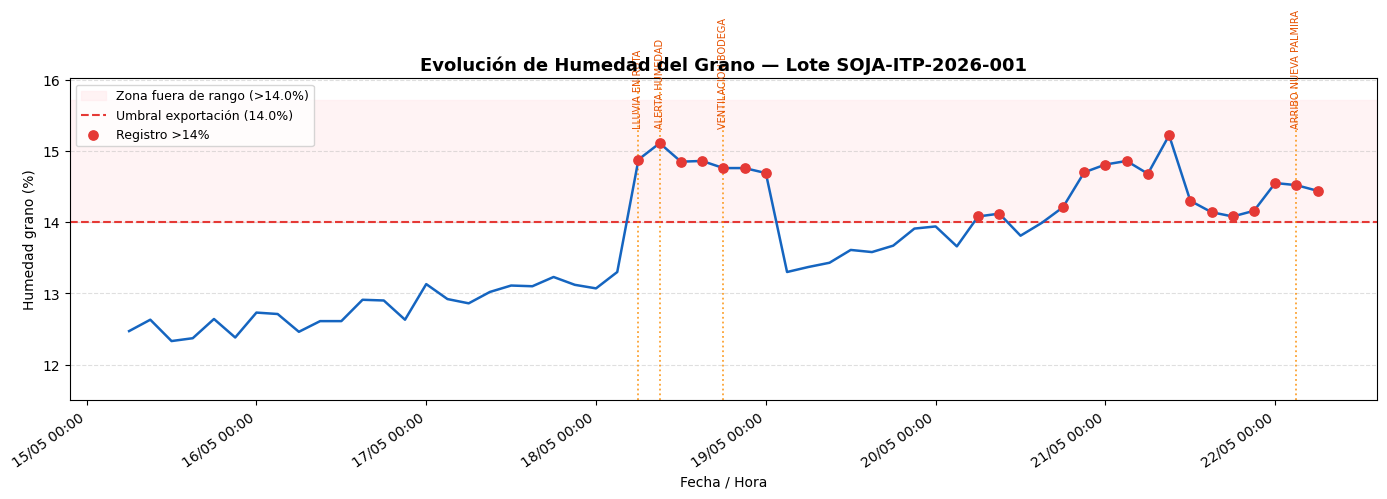


Registros con humedad >14%: 22 de 57


In [7]:
UMBRAL_HUMEDAD = 14.0

fig, ax = plt.subplots(figsize=(14, 5))

# Zona de alerta
ax.axhspan(UMBRAL_HUMEDAD, df["humedad_grano_pct"].max() + 0.5,
           color="#FFEBEE", alpha=0.6, label=f"Zona fuera de rango (>{UMBRAL_HUMEDAD}%)")
ax.axhline(UMBRAL_HUMEDAD, color="#E53935", linewidth=1.5,
           linestyle="--", label=f"Umbral exportación ({UMBRAL_HUMEDAD}%)")

# Serie principal
ax.plot(df["timestamp"], df["humedad_grano_pct"],
        color="#1565C0", linewidth=1.8, zorder=3)

# Puntos fuera de rango
fuera = df[df["humedad_grano_pct"] > UMBRAL_HUMEDAD]
ax.scatter(fuera["timestamp"], fuera["humedad_grano_pct"],
           color="#E53935", s=45, zorder=5, label="Registro >14%")

# Eventos clave marcados con línea vertical
eventos_marcar = df[df["evento"].isin(["ALERTA_HUMEDAD", "LLUVIA_EN_RUTA",
                                        "VENTILACION_BODEGA", "ARRIBO_NUEVA_PALMIRA"])]
for _, ev in eventos_marcar.iterrows():
    ax.axvline(ev["timestamp"], color="#FB8C00", linestyle=":", linewidth=1.3, alpha=0.8)
    ax.text(ev["timestamp"], df["humedad_grano_pct"].max() + 0.1,
            ev["evento"].replace("_", " "), fontsize=7, rotation=90,
            va="bottom", ha="center", color="#E65100")

ax.set_title("Evolución de Humedad del Grano — Lote SOJA-ITP-2026-001", fontsize=13, fontweight="bold")
ax.set_xlabel("Fecha / Hora")
ax.set_ylabel("Humedad grano (%)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
plt.xticks(rotation=35, ha="right")
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_ylim(11.5, df["humedad_grano_pct"].max() + 0.8)
plt.tight_layout()
plt.savefig("humedad_grano.png", dpi=150)
plt.show()
print(f"\nRegistros con humedad >14%: {len(fuera)} de {len(df)}")

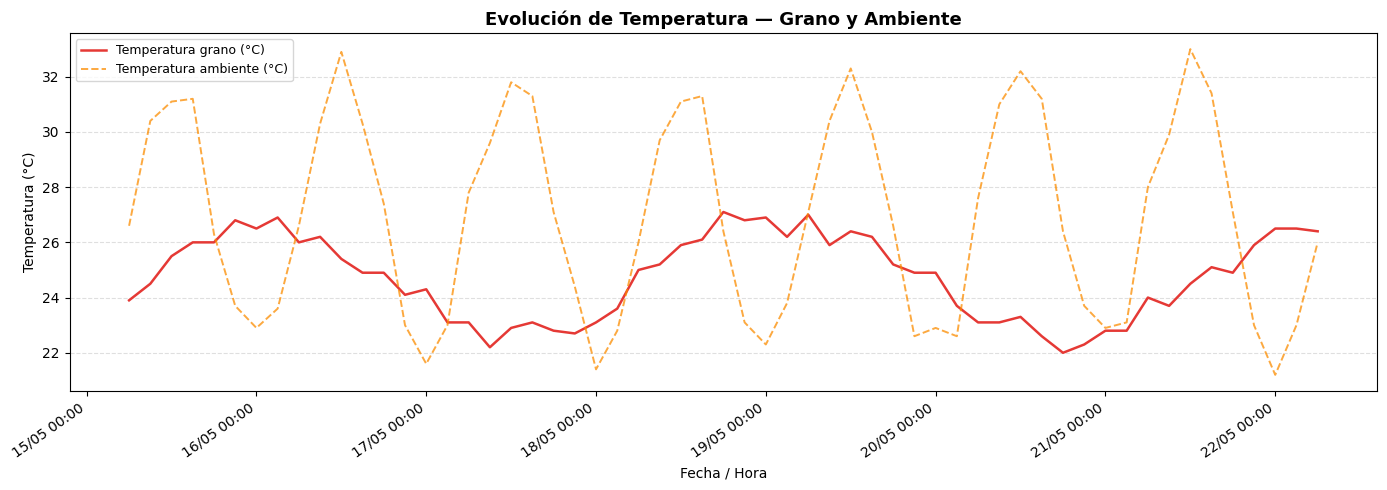

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["timestamp"], df["temperatura_grano_c"],
        color="#E53935", linewidth=1.8, label="Temperatura grano (°C)")
ax.plot(df["timestamp"], df["temperatura_ambiente_c"],
        color="#FB8C00", linewidth=1.4, linestyle="--", alpha=0.75,
        label="Temperatura ambiente (°C)")

ax.set_title("Evolución de Temperatura — Grano y Ambiente", fontsize=13, fontweight="bold")
ax.set_xlabel("Fecha / Hora")
ax.set_ylabel("Temperatura (°C)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
plt.xticks(rotation=35, ha="right")
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("temperatura.png", dpi=150)
plt.show()

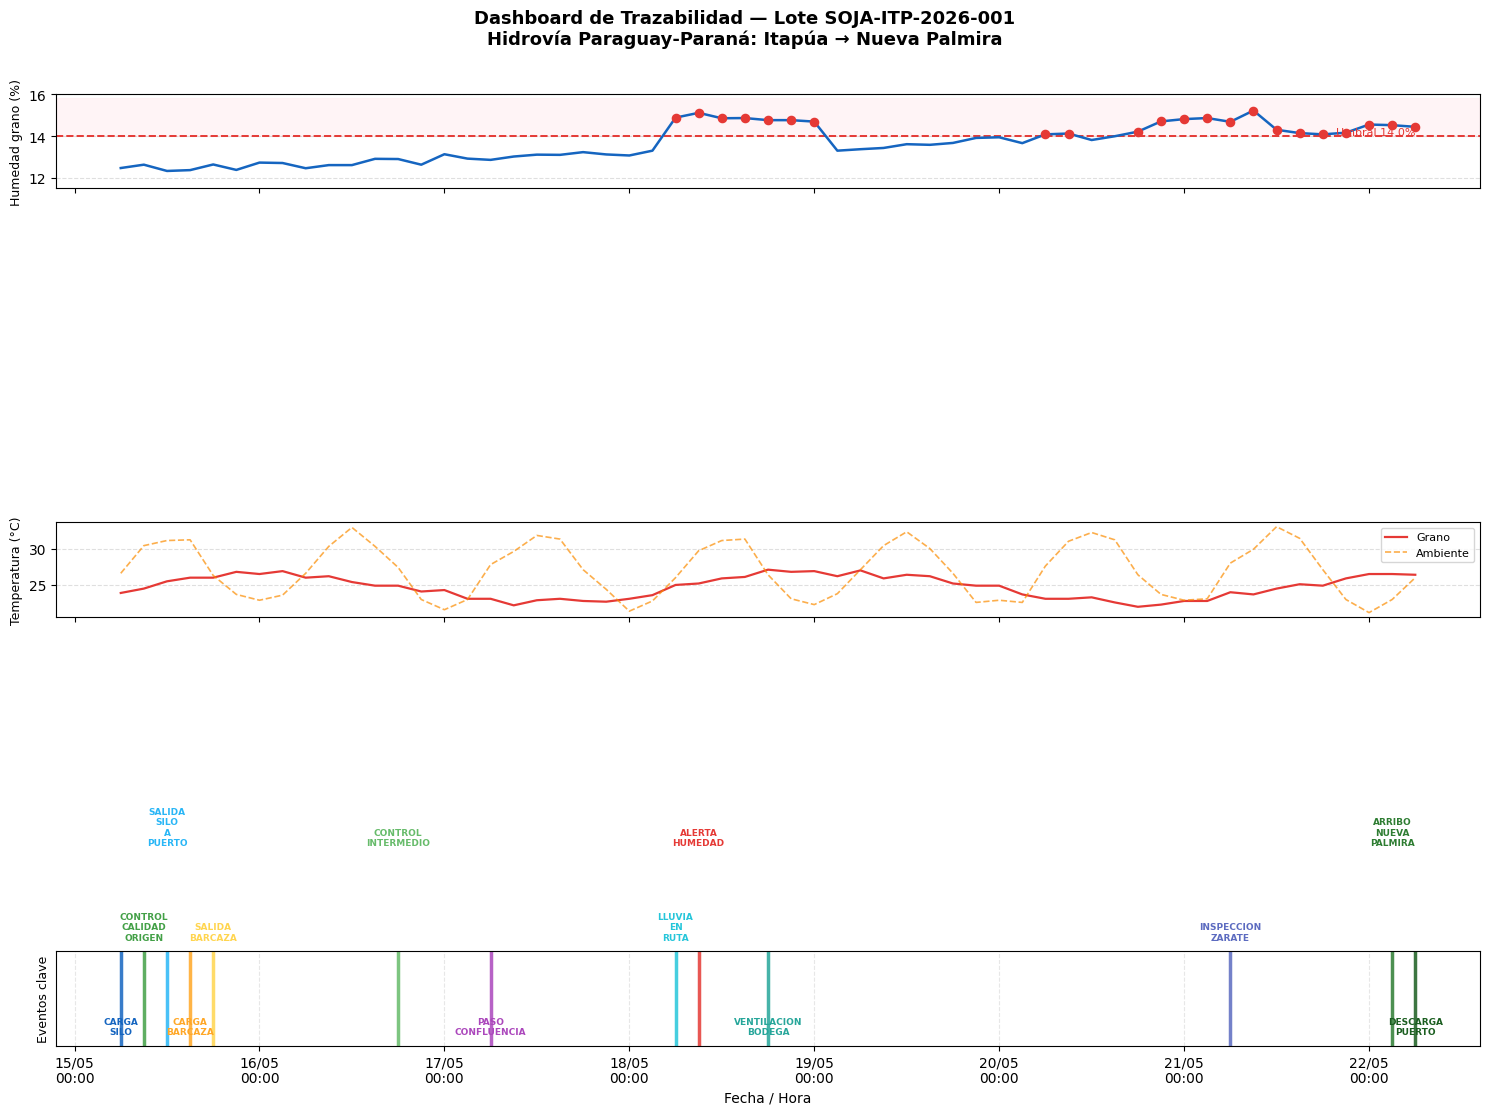

In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
fig.suptitle("Dashboard de Trazabilidad — Lote SOJA-ITP-2026-001\nHidrovía Paraguay-Paraná: Itapúa → Nueva Palmira",
             fontsize=13, fontweight="bold", y=1.01)

# — Panel 1: Humedad grano —
ax1.axhspan(UMBRAL_HUMEDAD, df["humedad_grano_pct"].max() + 0.6,
            color="#FFEBEE", alpha=0.5)
ax1.axhline(UMBRAL_HUMEDAD, color="#E53935", linewidth=1.4, linestyle="--")
ax1.plot(df["timestamp"], df["humedad_grano_pct"],
         color="#1565C0", linewidth=1.8)
ax1.scatter(fuera["timestamp"], fuera["humedad_grano_pct"],
            color="#E53935", s=35, zorder=5)
ax1.set_ylabel("Humedad grano (%)", fontsize=9)
ax1.set_ylim(11.5, df["humedad_grano_pct"].max() + 0.8)
ax1.text(df["timestamp"].max(), UMBRAL_HUMEDAD + 0.05,
         f"Umbral {UMBRAL_HUMEDAD}%", color="#E53935", fontsize=8, ha="right")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# — Panel 2: Temperatura —
ax2.plot(df["timestamp"], df["temperatura_grano_c"],
         color="#E53935", linewidth=1.6, label="Grano")
ax2.plot(df["timestamp"], df["temperatura_ambiente_c"],
         color="#FB8C00", linewidth=1.2, linestyle="--", alpha=0.7, label="Ambiente")
ax2.set_ylabel("Temperatura (°C)", fontsize=9)
ax2.legend(fontsize=8, loc="upper right")
ax2.grid(axis="y", linestyle="--", alpha=0.4)

# — Panel 3: Eventos logísticos —
eventos_todos = df[df["evento"] != "TELEMETRIA"].copy()
colores_evento = {
    "CARGA_SILO":           "#1565C0",
    "CONTROL_CALIDAD_ORIGEN":"#43A047",
    "SALIDA_SILO_A_PUERTO": "#29B6F6",
    "CARGA_BARCAZA":        "#FFA726",
    "SALIDA_BARCAZA":       "#FFD54F",
    "CONTROL_INTERMEDIO":   "#66BB6A",
    "PASO_CONFLUENCIA":     "#AB47BC",
    "LLUVIA_EN_RUTA":       "#26C6DA",
    "ALERTA_HUMEDAD":       "#E53935",
    "VENTILACION_BODEGA":   "#26A69A",
    "INSPECCION_ZARATE":    "#5C6BC0",
    "ARRIBO_NUEVA_PALMIRA": "#2E7D32",
    "DESCARGA_PUERTO":      "#1B5E20",
}

for i, (_, ev) in enumerate(eventos_todos.iterrows()):
    color = colores_evento.get(ev["evento"], "#9E9E9E")
    ax3.axvline(ev["timestamp"], color=color, linewidth=2.5, alpha=0.85)
    ax3.text(ev["timestamp"], i % 3 + 0.1,
             ev["evento"].replace("_", "\n"), fontsize=6.5, ha="center",
             va="bottom", color=color, fontweight="bold")

ax3.set_ylabel("Eventos clave", fontsize=9)
ax3.set_yticks([])
ax3.set_xlabel("Fecha / Hora")
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m\n%H:%M"))
ax3.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("dashboard_trazabilidad.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
cols_tabla = ["registro_id", "timestamp", "ubicacion", "etapa", "evento",
              "humedad_grano_pct", "temperatura_grano_c", "transporte", "observaciones"]

fuera_rango = df[df["humedad_grano_pct"] > UMBRAL_HUMEDAD][cols_tabla].copy()
fuera_rango = fuera_rango.rename(columns={
    "registro_id":        "ID",
    "timestamp":          "Fecha/Hora",
    "ubicacion":          "Ubicación",
    "etapa":              "Etapa",
    "evento":             "Evento",
    "humedad_grano_pct":  "Humedad (%)",
    "temperatura_grano_c":"Temp. grano (°C)",
    "transporte":         "Transporte",
    "observaciones":      "Observaciones",
})

print(f"╔══════════════════════════════════════════════════════════╗")
print(f"  REGISTROS CON HUMEDAD > {UMBRAL_HUMEDAD}%  ({len(fuera_rango)} registros de {len(df)})")
print(f"╚══════════════════════════════════════════════════════════╝")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 40)
print(fuera_rango.to_string(index=False))

# Exportar tabla a CSV
fuera_rango.to_csv("humedad_fuera_rango.csv", index=False)
print("\n📄 Tabla exportada: humedad_fuera_rango.csv")

╔══════════════════════════════════════════════════════════╗
  REGISTROS CON HUMEDAD > 14.0%  (22 registros de 57)
╚══════════════════════════════════════════════════════════╝
      ID          Fecha/Hora                    Ubicación            Etapa               Evento  Humedad (%)  Temp. grano (°C)     Transporte                                               Observaciones
TRZ-0025 2026-05-18 06:00:00  Tramo Corrientes - Santa Fe TRANSITO_FLUVIAL       LLUVIA_EN_RUTA        14.88              25.0        Barcaza Condición climática adversa; revisar ventilación y sellado.
TRZ-0026 2026-05-18 09:00:00  Tramo Corrientes - Santa Fe TRANSITO_FLUVIAL       ALERTA_HUMEDAD        15.11              25.2        Barcaza Humedad del grano supera umbral recomendado de exportación.
TRZ-0027 2026-05-18 12:00:00  Tramo Corrientes - Santa Fe TRANSITO_FLUVIAL           TELEMETRIA        14.85              25.9        Barcaza                      Registro automático de telemetría IoT.
TRZ-0028 2026-05

In [14]:

hum_llegada       = df.iloc[-1]["humedad_grano_pct"]
hum_max           = df["humedad_grano_pct"].max()
hum_prom          = df["humedad_grano_pct"].mean()
hum_prom_final    = df.tail(5)["humedad_grano_pct"].mean()  # últimos 5 registros
pct_fuera         = len(fuera_rango) / len(df) * 100
temp_llegada      = df.iloc[-1]["temperatura_grano_c"]
sello_llegada     = df.iloc[-1]["estado_sello"]
alerta_presente   = "ALERTA_HUMEDAD" in df["evento"].values
ventilacion_hecha = "VENTILACION_BODEGA" in df["evento"].values

# Humedad de llegada dentro del umbral
apto = hum_llegada <= UMBRAL_HUMEDAD

print("=" * 60)
print("   EVALUACIÓN FINAL — CONDICIÓN DE EXPORTACIÓN")
print("=" * 60)
print(f"  Humedad al llegar a Nueva Palmira : {hum_llegada:.2f}%")
print(f"  Temperatura grano en destino      : {temp_llegada:.1f} °C")
print(f"  Estado de sello en destino        : {sello_llegada}")
print(f"  Humedad máxima registrada en viaje: {hum_max:.2f}%")
print(f"  Humedad promedio de viaje         : {hum_prom:.2f}%")
print(f"  Promedio últimos 5 registros      : {hum_prom_final:.2f}%")
print(f"  Registros con humedad >14%        : {len(fuera_rango)} ({pct_fuera:.1f}%)")
print(f"  Evento ALERTA_HUMEDAD registrado  : {'Sí ' if alerta_presente else 'No'}")
print(f"  Ventilación de bodega aplicada    : {'Sí ' if ventilacion_hecha else 'No'}")
print()

if apto:
    print("   RESULTADO: LOTE APTO PARA EXPORTACIÓN")
    print(f"     La humedad al arribo ({hum_llegada:.2f}%) se encuentra")
    print(f"     por debajo del umbral de {UMBRAL_HUMEDAD}%.")
else:
    print("   RESULTADO: LOTE NO APTO — humedad fuera de rango en destino")

print()
print("  ── ANÁLISIS DE MOMENTOS CRÍTICOS ──")
if alerta_presente:
    ev_alerta = df[df["evento"] == "ALERTA_HUMEDAD"].iloc[0]
    print(f"   CRÍTICO: Alerta de humedad ({ev_alerta['humedad_grano_pct']:.2f}%) el")
    print(f"     {ev_alerta['timestamp']}  en  {ev_alerta['ubicacion']}")
if ventilacion_hecha:
    ev_vent = df[df["evento"] == "VENTILACION_BODEGA"].iloc[0]
    print(f"   ACCIÓN: Ventilación de bodega aplicada el")
    print(f"     {ev_vent['timestamp']}  —  {ev_vent['observaciones']}")
lluvia = df[df["evento"] == "LLUVIA_EN_RUTA"]
if not lluvia.empty:
    ev_lluvia = lluvia.iloc[0]
    print(f"    RIESGO: Lluvia en ruta registrada el")
    print(f"     {ev_lluvia['timestamp']}  en  {ev_lluvia['ubicacion']}")

print()
print("  ── JUSTIFICACIÓN ──")
print(f"  Si bien el {pct_fuera:.1f}% de los registros superó el umbral del")
print(f"  {UMBRAL_HUMEDAD}%, se identificó la causa (lluvia/humedad ambiente).")
print(f"  Se aplicó ventilación de bodega correctiva, y la humedad")
print(f"  descendió a {hum_prom_final:.2f}% (promedio final) llegando a")
print(f"  {hum_llegada:.2f}% al arribo. El sello del lote llegó en estado")
print(f"  '{sello_llegada}', lo que confirma la integridad del proceso.")

   EVALUACIÓN FINAL — CONDICIÓN DE EXPORTACIÓN
  Humedad al llegar a Nueva Palmira : 14.44%
  Temperatura grano en destino      : 26.4 °C
  Estado de sello en destino        : OK
  Humedad máxima registrada en viaje: 15.22%
  Humedad promedio de viaje         : 13.65%
  Promedio últimos 5 registros      : 14.35%
  Registros con humedad >14%        : 22 (38.6%)
  Evento ALERTA_HUMEDAD registrado  : Sí 
  Ventilación de bodega aplicada    : Sí 

   RESULTADO: LOTE NO APTO — humedad fuera de rango en destino

  ── ANÁLISIS DE MOMENTOS CRÍTICOS ──
   CRÍTICO: Alerta de humedad (15.11%) el
     2026-05-18 09:00:00  en  Tramo Corrientes - Santa Fe
   ACCIÓN: Ventilación de bodega aplicada el
     2026-05-18 18:00:00  —  Se registra ventilación correctiva por aumento de humedad.
    RIESGO: Lluvia en ruta registrada el
     2026-05-18 06:00:00  en  Tramo Corrientes - Santa Fe

  ── JUSTIFICACIÓN ──
  Si bien el 38.6% de los registros superó el umbral del
  14.0%, se identificó la causa (lluvi